In [2]:
# importing the libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline   

In [3]:
# loading the dataset

df = pd.read_csv("airline_ticket_prices_dataset.csv")
df.sample(5)  

,Ticket_ID,Airline,Origin,Destination,Distance_km,Class,Days_Before_Departure,Price_USD
26,27,Saudia,Istanbul,Cairo,2880,Economy,38,507.24
74,75,Etihad,Riyadh,Mumbai,3075,Economy,32,631.08
8,9,Qatar Airways,Paris,Riyadh,7150,Business,24,3032.38
17,18,Lufthansa,New York,Riyadh,11244,Economy,37,1929.27
209,210,Etihad,New York,Cairo,11384,Economy,11,2472.36


In [5]:
# statistical summary of the data

df.describe()   

,Ticket_ID,Distance_km,Days_Before_Departure,Price_USD
count,250.000000,250.000000,250.000000,250.000000
mean,125.500000,5999.952000,59.024000,2006.059760
std,72.312977,3401.695261,33.736628,1675.067217
min,1.000000,336.000000,1.000000,106.070000
25%,63.250000,2991.750000,31.250000,818.665000
50%,125.500000,6132.500000,60.500000,1531.235000
75%,187.750000,8832.750000,86.750000,2590.357500
max,250.000000,11903.000000,118.000000,8852.690000


     Ticket_ID  Distance_km  Days_Before_Departure  Price_USD
234        235         5058                     65    2398.78
90          91         5613                     30    2297.97
177        178         6188                     78    2396.76


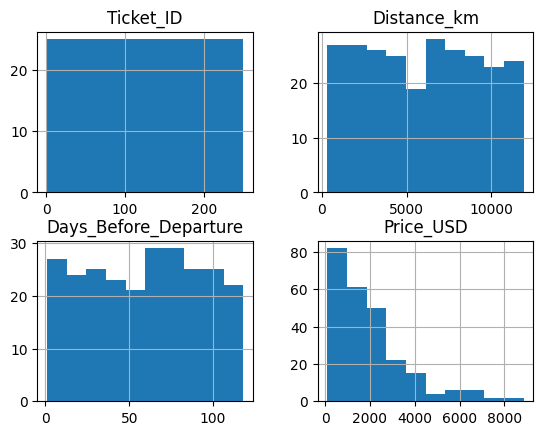

In [7]:
# visualizing the features 

cdf = df[['Ticket_ID','Distance_km','Days_Before_Departure','Price_USD']]
print(cdf.sample(3))
cdf.hist()  
plt.show()    

In [14]:
#  Dropping unnecessary column
df = df.drop("Ticket_ID", axis=1)

In [16]:
# Converting categorical → numerical
df = pd.get_dummies(df, drop_first=True)

In [17]:
# defining the input and output (X and Y)

X = df.drop("Price_USD", axis=1)
Y = df["Price_USD"]

In [18]:
# train test split 

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)


In [ ]:
# Train Multiple Linear Regression Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [20]:
#  Model Coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 479.06145554428485
Coefficients: [ 3.24685397e-01 -1.40733977e+01  8.65306615e+01 -1.00312336e+02
 -6.77340039e+01  4.03635400e+01 -5.27125786e+01  1.54622435e+02
 -2.42652901e+02  6.27398718e+02  1.42571524e+02  1.21180065e+02
  1.04578206e+02  5.20224303e+02  4.68318041e+02 -9.43873747e+01
  1.12274015e+02  4.55976842e+01  9.63635914e+01 -8.51366345e+01
  4.05354282e+02  2.44257684e+02  1.03981558e+02  4.28918709e+02
  2.11020185e+01  2.33916105e+02  2.38295957e+02 -1.00254003e+03
  1.15764147e+03]


In [21]:
# predictions 

Y_pred = model.predict(X_test)

In [22]:
#  Evaluation
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 774485.171774616
RMSE: 880.0483917232143
R2 Score: 0.7639499768289928


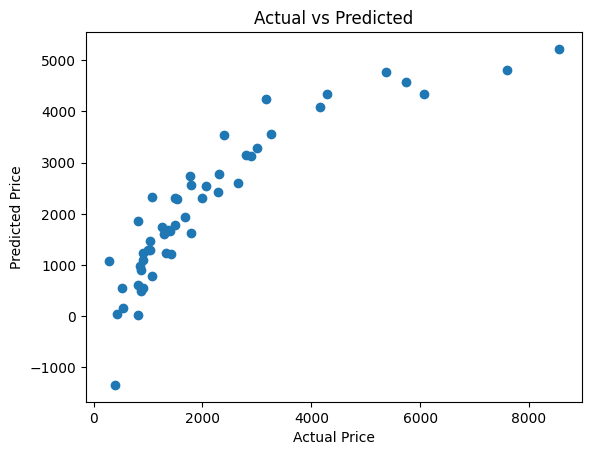

In [23]:
#  Visualization
plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()